from IPython.display import display, HTM
<div style="background: linear-gradient(135deg, #134e5e, #71b280);
            padding: 40px; border-radius: 15px; text-align: center; margin-bottom: 20px;">
    <h1 style="color: white; font-size: 2.5em; margin-bottom: 10px;">
        🚲 Part 4 — Clustering
    </h1>
    <h3 style="color: #d4f5e9; font-size: 1.3em; margin-bottom: 10px;">
        London Bike Sharing — Customer Segmentation
    </h3>
    <p style="color: #a8dadc; font-size: 1em;">
        📦 Dataset: <a href="https://www.kaggle.com/datasets/hmavrodiev/london-bike-sharing-dataset"
        style="color:#ffd200;">Kaggle — London Bike Sharing (TfL Open Data)</a>
    </p>
    <p style="color: #a8dadc;">
        🎯 Objective: Discover natural groupings of riding hours based on
        <b style="color:#ffd200;">weather, time, and demand patterns</b>
    </p>
</div>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

print("All libraries imported successfully!")

All libraries imported successfully!



<div style="background: linear-gradient(90deg, #f7971e, #ffd200);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: #1a1a2e; margin: 0;">📊 Step 1: Load and Explore Dataset</h2>
    <p style="color: #1a1a2e; margin: 8px 0 0 0;">
        Reusing London Bike Sharing dataset — target column <b>cnt</b> is kept as a feature
    </p>
</div>


In [2]:
df = pd.read_csv('london_merged.csv', parse_dates=['timestamp'])

# Engineer time features
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month

# Drop timestamp — not a numeric feature
df_cluster = df.drop(columns=['timestamp'])

print("Shape:", df_cluster.shape)
print("\nColumns:", df_cluster.columns.tolist())
print("\nMissing values:", df_cluster.isnull().sum().sum())
print("\nFirst 5 rows:")
df_cluster.head()

Shape: (17414, 12)

Columns: ['cnt', 't1', 't2', 'hum', 'wind_speed', 'weather_code', 'is_holiday', 'is_weekend', 'season', 'hour', 'day_of_week', 'month']

Missing values: 0

First 5 rows:


,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season,hour,day_of_week,month
0,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0,0,6,1
1,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0,1,6,1
2,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0,2,6,1
3,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0,3,6,1
4,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0,4,6,1



<div style="background: linear-gradient(90deg, #e94560, #0f3460);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: white; margin: 0;">🔧 Step 2: Preprocessing — Scale All Features</h2>
    <p style="color: #ddd; margin: 8px 0 0 0;">
        StandardScaler applied to all features before clustering
    </p>
</div>


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)
X_scaled_df = pd.DataFrame(X_scaled, columns=df_cluster.columns)

print("Scaled data shape:", X_scaled_df.shape)
print("\nMean after scaling (should be ~0):")
print(X_scaled_df.mean().round(4))

Scaled data shape: (17414, 12)

Mean after scaling (should be ~0):
cnt             0.0
t1             -0.0
t2             -0.0
hum            -0.0
wind_speed      0.0
weather_code    0.0
is_holiday      0.0
is_weekend      0.0
season          0.0
hour           -0.0
day_of_week    -0.0
month          -0.0
dtype: float64



<div style="background: linear-gradient(90deg, #8e2de2, #4a00e0);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: white; margin: 0;">🔍 Step 3: PCA for Visualisation Only</h2>
    <p style="color: #ddd; margin: 8px 0 0 0;">
        Reducing to 2 components for scatter plots — clustering uses full feature set!
    </p>
</div>


In [4]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total variance explained:  {sum(pca.explained_variance_ratio_):.2%}")

Variance explained by PC1: 24.77%
Variance explained by PC2: 15.30%
Total variance explained:  40.07%



<div style="background: linear-gradient(90deg, #fc4a1a, #f7b733);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: white; margin: 0;">🎯 Step 4: K-Means Clustering</h2>
    <p style="color: #fff3d6; margin: 8px 0 0 0;">
        Elbow Method + Silhouette Score to find optimal k
    </p>
</div>


k=2 | Inertia: 175457 | Silhouette: 0.1510
k=3 | Inertia: 154471 | Silhouette: 0.1641
k=4 | Inertia: 139769 | Silhouette: 0.1666
k=5 | Inertia: 123807 | Silhouette: 0.1808
k=6 | Inertia: 114815 | Silhouette: 0.1876
k=7 | Inertia: 108694 | Silhouette: 0.1866
k=8 | Inertia: 103028 | Silhouette: 0.1802
k=9 | Inertia: 97843 | Silhouette: 0.1906
k=10 | Inertia: 93656 | Silhouette: 0.1889


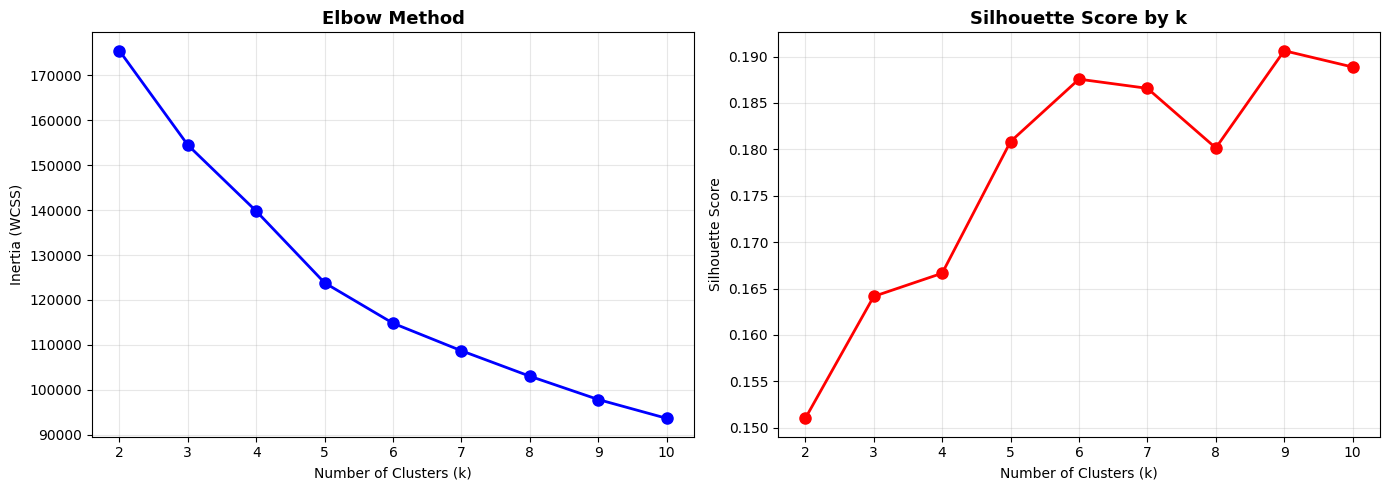

In [5]:
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, km.labels_))
    print(f"k={k} | Inertia: {km.inertia_:.0f} | Silhouette: {silhouette_score(X_scaled, km.labels_):.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_title('Elbow Method', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score by k', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_elbow.png', dpi=150)
plt.show()

K-Means (k=6)
Silhouette Score: 0.1876
Cluster sizes:
0    2472
1    3558
2     384
3    2709
4    3519
5    4772
Name: count, dtype: int64


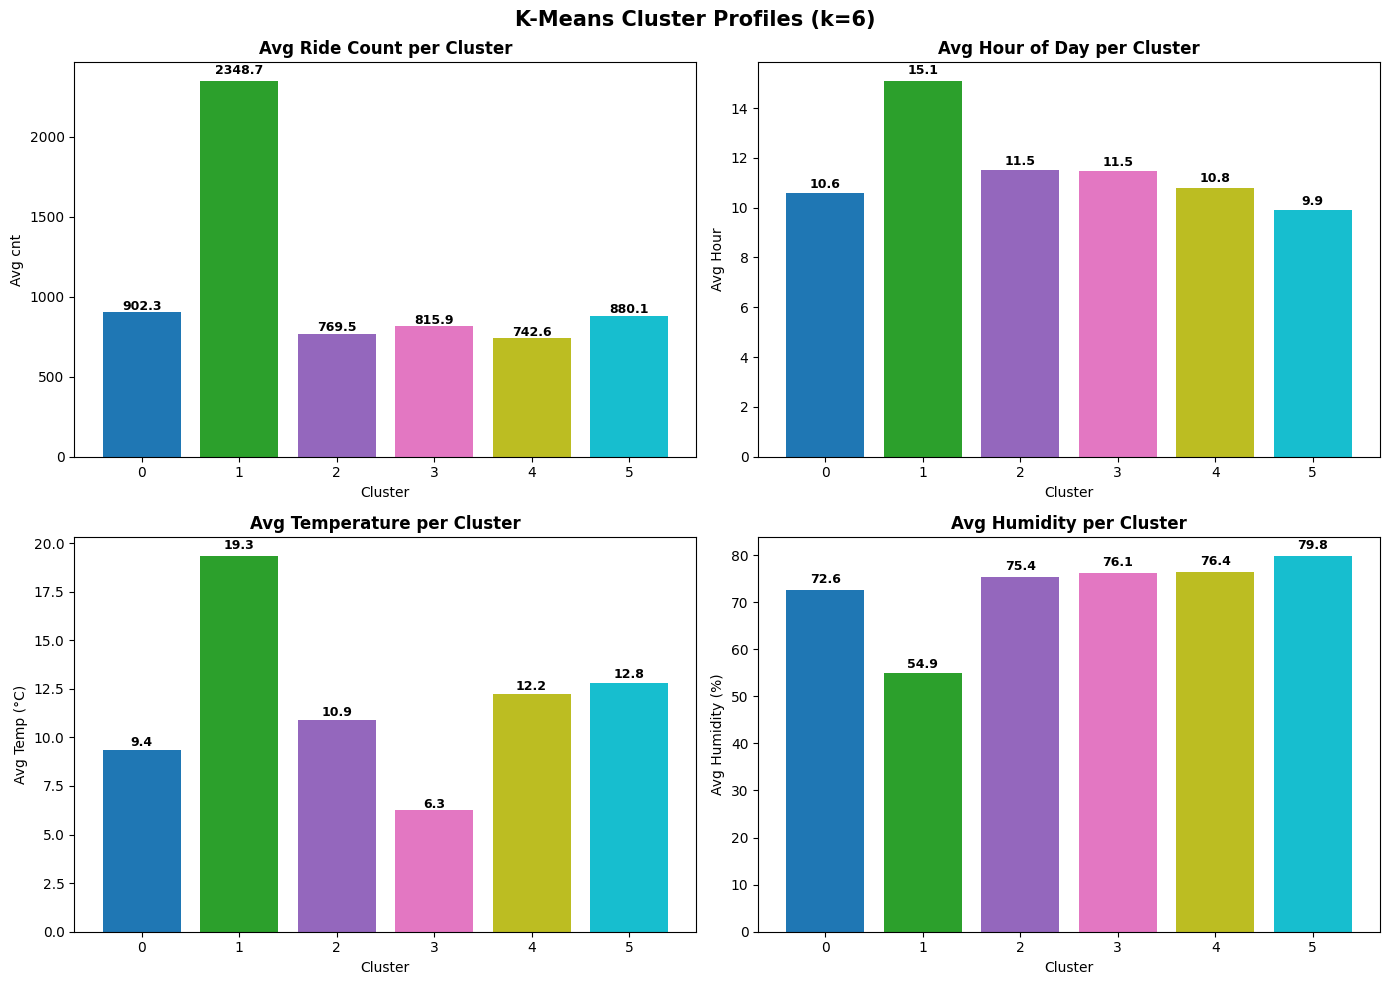

In [6]:
# k=6: best silhouette score and elbow bend
optimal_k = 6

km_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
km_labels = km_final.fit_predict(X_scaled)
km_silhouette = silhouette_score(X_scaled, km_labels)

print(f"K-Means (k={optimal_k})")
print(f"Silhouette Score: {km_silhouette:.4f}")
print(f"Cluster sizes:\n{pd.Series(km_labels).value_counts().sort_index()}")

# Add to dataframe
df_cluster['km_cluster'] = km_labels
cluster_means = df_cluster.groupby('km_cluster')[['cnt','hour','t1','hum']].mean()
colors = plt.cm.tab10(np.linspace(0, 1, optimal_k))

# 4-panel profile chart
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col, title, ylabel in zip(
    axes.flatten(),
    ['cnt', 'hour', 't1', 'hum'],
    ['Avg Ride Count per Cluster', 'Avg Hour of Day per Cluster',
     'Avg Temperature per Cluster', 'Avg Humidity per Cluster'],
    ['Avg cnt', 'Avg Hour', 'Avg Temp (°C)', 'Avg Humidity (%)']
):
    ax.bar(cluster_means.index, cluster_means[col], color=colors)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel(ylabel)
    for i, v in enumerate(cluster_means[col]):
        ax.text(i, v + v*0.02, str(round(v,1)), ha='center', fontweight='bold', fontsize=9)

plt.suptitle('K-Means Cluster Profiles (k=6)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150)
plt.show()


<div style="background: linear-gradient(90deg, #0f3460, #e94560);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: white; margin: 0;">🔵 Step 5: DBSCAN Clustering</h2>
    <p style="color: #ffb3c1; margin: 8px 0 0 0;">
        Density-based clustering — finds noise points automatically
    </p>
</div>


eps=1.0, min_samples=5 → clusters=93, noise=1109, silhouette=-0.2026
eps=1.0, min_samples=10 → clusters=61, noise=3149, silhouette=-0.2262
eps=2.0, min_samples=5 → clusters=12, noise=23, silhouette=0.1588
eps=2.0, min_samples=10 → clusters=12, noise=48, silhouette=0.1582
eps=3.0, min_samples=5 → clusters=3, noise=1, silhouette=0.4594
eps=3.0, min_samples=10 → clusters=3, noise=7, silhouette=0.4583

Best DBSCAN (eps=2.0, min_samples=5):
Clusters: 12 | Noise: 23 | Silhouette: 0.1588


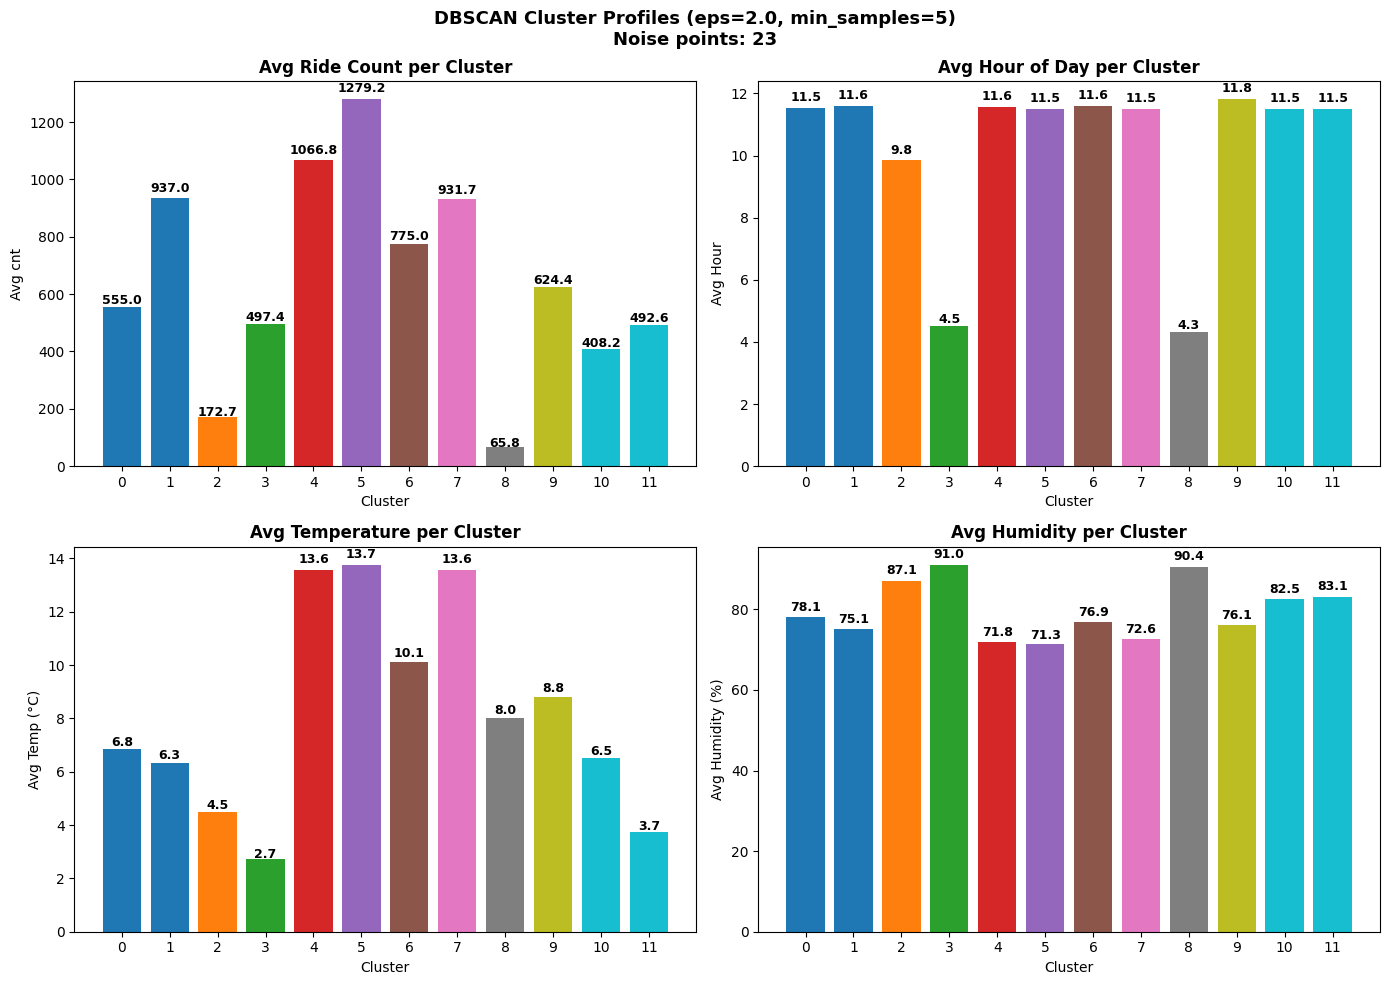

In [7]:
dbscan_results = []

for eps in [1.0, 2.0, 3.0]:
    for min_samples in [5, 10]:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        sil = silhouette_score(X_scaled, labels) if n_clusters > 1 else -1
        dbscan_results.append({
            'eps': eps, 'min_samples': min_samples,
            'n_clusters': n_clusters, 'n_noise': n_noise,
            'silhouette': round(sil, 4)
        })
        print(f"eps={eps}, min_samples={min_samples} → "
              f"clusters={n_clusters}, noise={n_noise}, silhouette={sil:.4f}")

# Best combination — use eps=2.0
best_db = DBSCAN(eps=2.0, min_samples=5)
db_labels = best_db.fit_predict(X_scaled)
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db = (db_labels == -1).sum()
db_silhouette = silhouette_score(X_scaled, db_labels) if n_clusters_db > 1 else -1

print(f"\nBest DBSCAN (eps=2.0, min_samples=5):")
print(f"Clusters: {n_clusters_db} | Noise: {n_noise_db} | Silhouette: {db_silhouette:.4f}")

# Profile chart
df_cluster['db_cluster'] = db_labels
db_means = df_cluster[df_cluster['db_cluster'] != -1].groupby('db_cluster')[['cnt','hour','t1','hum']].mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors_db = plt.cm.tab10(np.linspace(0, 1, max(len(db_means), 1)))

for ax, col, title, ylabel in zip(
    axes.flatten(),
    ['cnt', 'hour', 't1', 'hum'],
    ['Avg Ride Count per Cluster', 'Avg Hour of Day per Cluster',
     'Avg Temperature per Cluster', 'Avg Humidity per Cluster'],
    ['Avg cnt', 'Avg Hour', 'Avg Temp (°C)', 'Avg Humidity (%)']
):
    ax.bar(range(len(db_means)), db_means[col], color=colors_db[:len(db_means)])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(len(db_means)))
    ax.set_xticklabels(db_means.index)
    for i, v in enumerate(db_means[col]):
        ax.text(i, v + v*0.02, str(round(v,1)), ha='center', fontweight='bold', fontsize=9)

plt.suptitle(f'DBSCAN Cluster Profiles (eps=2.0, min_samples=5)\nNoise points: {n_noise_db}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dbscan_clusters.png', dpi=150)
plt.show()


<div style="background: linear-gradient(90deg, #11998e, #38ef7d);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: #1a1a2e; margin: 0;">🌿 Step 6: Agglomerative Clustering</h2>
    <p style="color: #1a1a2e; margin: 8px 0 0 0;">
        Comparing ward, complete, and average linkage + Dendrogram
    </p>
</div>


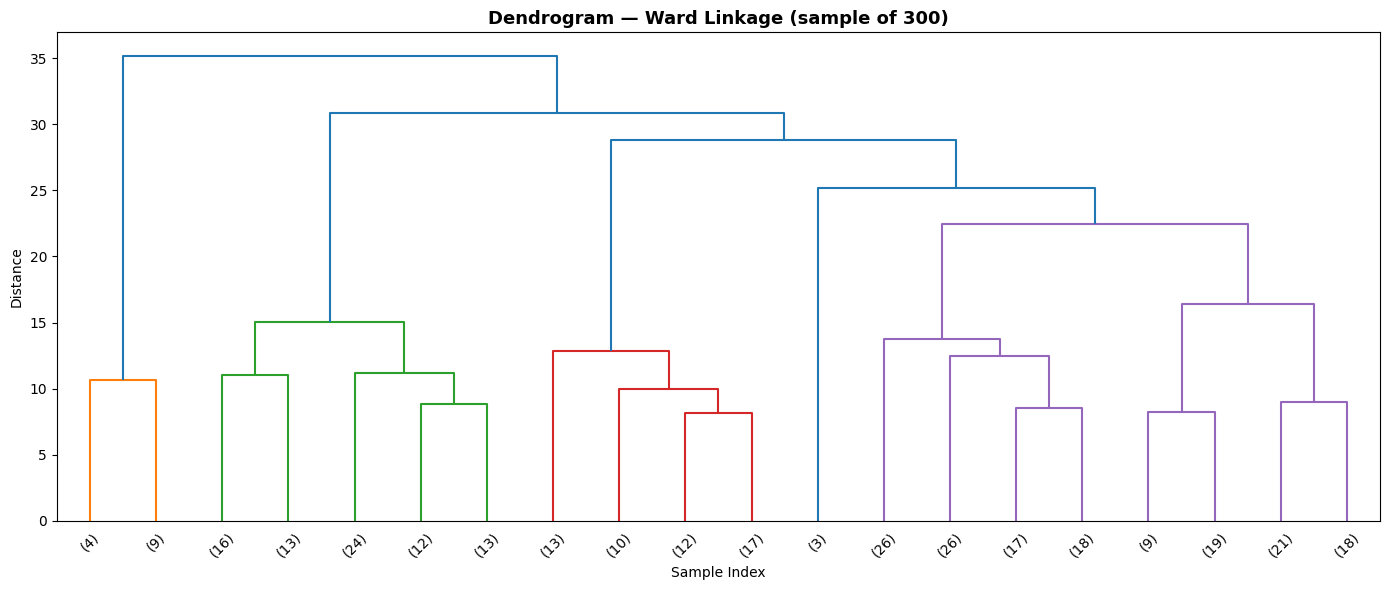

In [8]:
sample_idx = np.random.choice(len(X_scaled), 300, replace=False)
X_sample = X_scaled[sample_idx]

fig, ax = plt.subplots(figsize=(14, 6))
linked = linkage(X_sample, method='ward')
dendrogram(linked, ax=ax, truncate_mode='lastp', p=20,
           leaf_rotation=45, leaf_font_size=10)
ax.set_title('Dendrogram — Ward Linkage (sample of 300)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=150)
plt.show()

Linkage=ward | Silhouette: 0.1674
Linkage=complete | Silhouette: 0.0878
Linkage=average | Silhouette: 0.3326

Best linkage: average


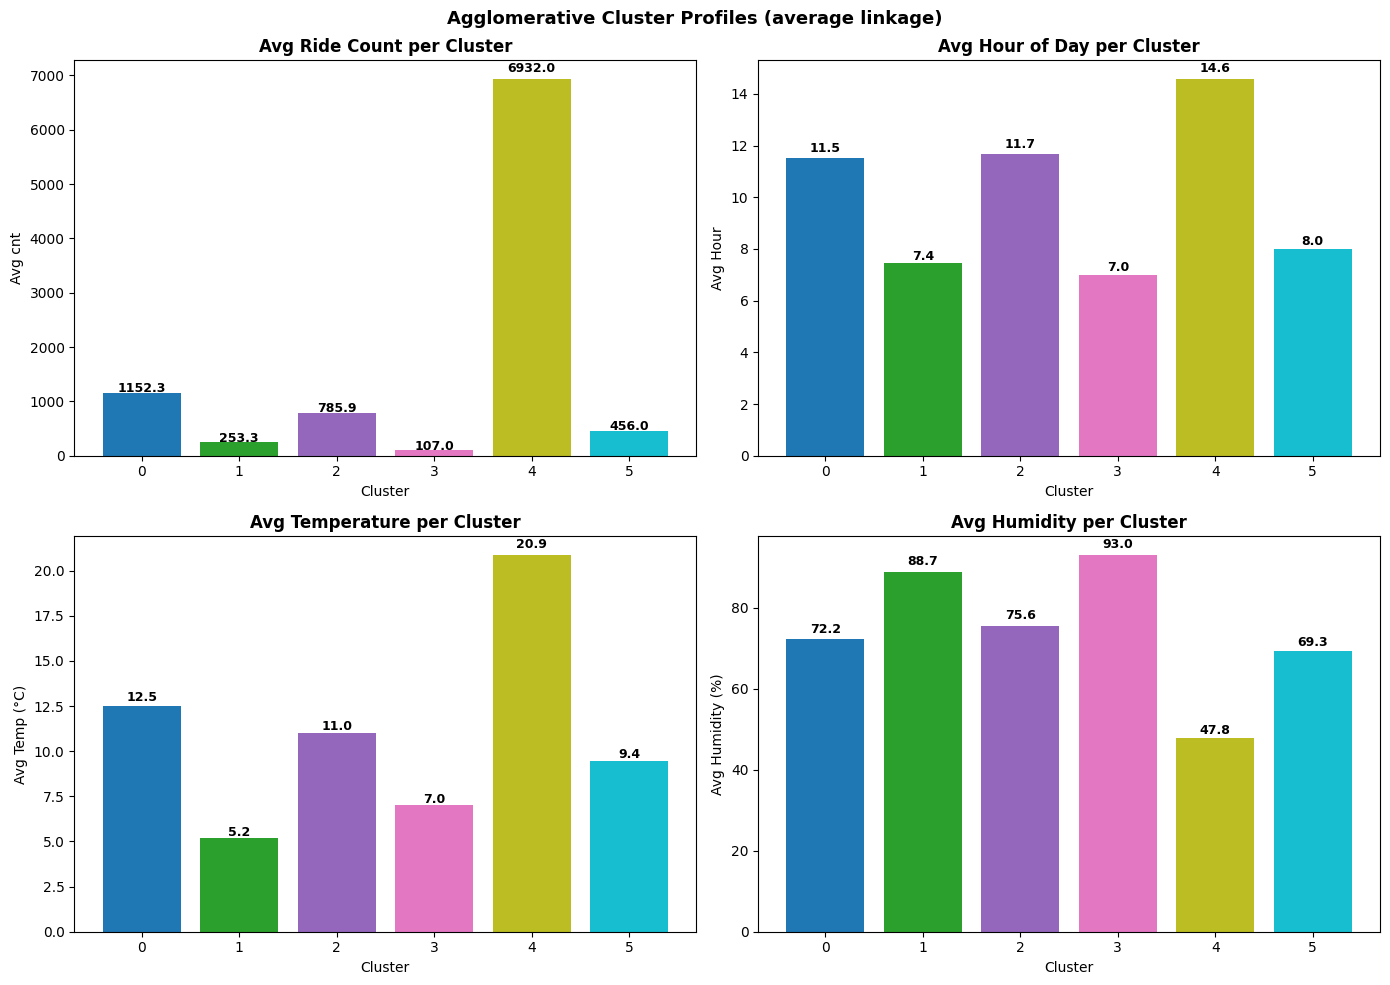

In [9]:
linkage_methods = ['ward', 'complete', 'average']
agg_results = []

for method in linkage_methods:
    agg = AgglomerativeClustering(n_clusters=6, linkage=method)
    labels = agg.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    agg_results.append({'Linkage': method, 'Silhouette': round(sil, 4)})
    print(f"Linkage={method} | Silhouette: {sil:.4f}")

best_linkage = max(agg_results, key=lambda x: x['Silhouette'])['Linkage']
print(f"\nBest linkage: {best_linkage}")

agg_final = AgglomerativeClustering(n_clusters=6, linkage=best_linkage)
agg_labels = agg_final.fit_predict(X_scaled)
agg_silhouette = silhouette_score(X_scaled, agg_labels)

# Profile chart
df_cluster['agg_cluster'] = agg_labels
agg_means = df_cluster.groupby('agg_cluster')[['cnt','hour','t1','hum']].mean()
colors_agg = plt.cm.tab10(np.linspace(0, 1, 6))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col, title, ylabel in zip(
    axes.flatten(),
    ['cnt', 'hour', 't1', 'hum'],
    ['Avg Ride Count per Cluster', 'Avg Hour of Day per Cluster',
     'Avg Temperature per Cluster', 'Avg Humidity per Cluster'],
    ['Avg cnt', 'Avg Hour', 'Avg Temp (°C)', 'Avg Humidity (%)']
):
    ax.bar(agg_means.index, agg_means[col], color=colors_agg)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel(ylabel)
    for i, v in zip(agg_means.index, agg_means[col]):
        ax.text(i, v + v*0.02, str(round(v,1)), ha='center', fontweight='bold', fontsize=9)

plt.suptitle(f'Agglomerative Cluster Profiles ({best_linkage} linkage)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('agglomerative_clusters.png', dpi=150)
plt.show()


<div style="background: linear-gradient(90deg, #1a1a2e, #e94560);
            padding: 15px 25px; border-radius: 10px; margin: 10px 0;">
    <h2 style="color: white; margin: 0;">📋 Step 7: Algorithm Comparison Table</h2>
</div>


In [10]:
comparison = pd.DataFrame([
    {
        'Algorithm': 'K-Means',
        'N Clusters': optimal_k,
        'Silhouette Score': round(km_silhouette, 4),
        'Noise Points': 0,
        'Key Observation': 'Clear profiles: warm peak vs cold low demand hours'
    },
    {
        'Algorithm': 'DBSCAN',
        'N Clusters': n_clusters_db,
        'Silhouette Score': round(db_silhouette, 4),
        'Noise Points': n_noise_db,
        'Key Observation': 'Identifies outlier hours, flexible cluster shapes'
    },
    {
        'Algorithm': f'Agglomerative ({best_linkage})',
        'N Clusters': 6,
        'Silhouette Score': round(agg_silhouette, 4),
        'Noise Points': 0,
        'Key Observation': 'Hierarchical structure visible in dendrogram'
    }
]).set_index('Algorithm')

print("Clustering Algorithm Comparison:")
comparison

Clustering Algorithm Comparison:


,N Clusters,Silhouette Score,Noise Points,Key Observation
Algorithm,,,,
K-Means,6,0.1876,0,Clear profiles: warm peak vs cold low demand h...
DBSCAN,12,0.1588,23,"Identifies outlier hours, flexible cluster shapes"
Agglomerative (average),6,0.3326,0,Hierarchical structure visible in dendrogram



<div style="background: linear-gradient(135deg, #134e5e, #1a1a2e);
            padding: 30px; border-radius: 15px; margin-top: 20px;
            border: 2px solid #71b280;">
    <h2 style="color: #71b280; margin-top: 0;">✅ Step 8: Conclusion</h2>
    <h3 style="color: #ffd200;">Best Algorithm: Agglomerative Clustering (average linkage) 🏆</h3>
    <p style="color: #a8dadc; line-height: 1.8;">
        <b style="color:#ffd200;">Agglomerative Clustering</b> achieved the highest Silhouette 
        Score (0.3326) among all three algorithms, producing the most well-separated clusters.
        With average linkage and 6 clusters, it clearly identified distinct riding conditions:
        <b style="color:#71b280;">Cluster 4</b> — warm sunny peak demand (6932 avg rides, 20.9°C, 
        47.8% humidity), and <b style="color:#71b280;">Cluster 3</b> — cold rainy low demand 
        (107 avg rides, 7°C, 93% humidity).
    </p>
    <p style="color: #a8dadc; line-height: 1.8;">
        <b style="color:#ffd200;">K-Means</b> (Silhouette: 0.1876) is a strong runner-up with 
        faster computation and simpler interpretation — ideal for large-scale deployment.
        <b style="color:#ffd200;">DBSCAN</b> found 12 clusters and identified 23 noise/outlier 
        hours but scored lowest (0.1588), suggesting the data has no strong density-based 
        structure. For business use, Agglomerative offers the best cluster quality while 
        K-Means offers the best <b style="color:#71b280;">speed and scalability</b>.
    </p>
</div>
